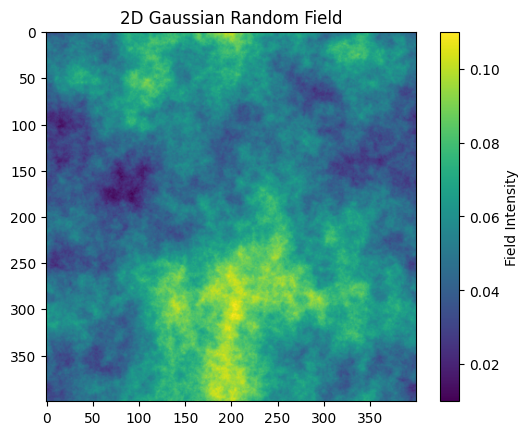

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_grf(size, alpha=3.0):
    """
    Generates a 2D Gaussian Random Field.
    
    Args:
        size: The dimension of one side of the square grid.
        alpha: The power-law index (smoothness). 
               Higher values = smoother fields.
    """
    # 1. Create a grid of coordinates in frequency space
    k = np.fft.fftfreq(size)
    kx, ky = np.meshgrid(k, k)
    
    # 2. Calculate the magnitude of frequency vectors |k|
    # We add a small epsilon to avoid division by zero at the origin
    k_mag = np.sqrt(kx**2 + ky**2)
    k_mag[0, 0] = 1.0 
    
    # 3. Generate complex Gaussian white noise in Fourier space
    # Real and imaginary parts are independent standard normals
    white_noise = np.random.randn(size, size) + 1j * np.random.randn(size, size)
    
    # 4. Apply the power-law filter: P(k) = 1 / |k|^alpha
    # We take the square root because we are scaling the amplitude, not power
    amplitude_filter = 1.0 / (k_mag ** (alpha / 2.0))
    amplitude_filter[0, 0] = 0.0 # Force mean to zero
    
    # 5. Multiply noise by filter and transform back to spatial domain
    field_fft = white_noise * amplitude_filter
    field = np.fft.ifft2(field_fft).real
    
    # 6. Normalize to [0, 1] for easy visualization/usage
    field = (field - np.min(field)) / (np.max(field) - np.min(field))
    return field

# --- Execution ---
grid_size = 400
smooth_field = 0.01 + 0.1 *generate_2d_grf(grid_size, alpha=3.0)

plt.imshow(smooth_field, cmap='viridis')
plt.colorbar(label="Field Intensity")
plt.title("2D Gaussian Random Field")
plt.show()

{'u': 4.2238059564636894e-08, 'v': 0.10446013738538558}


Running AlievPanfilov on (400, 400) Grid: 100%|██████████| 20000/20000 [00:02<00:00, 7475.38it/s]


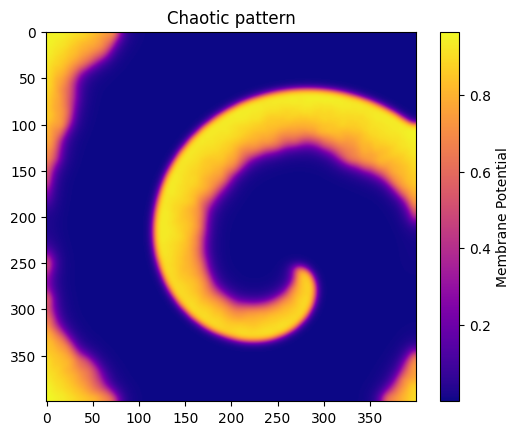

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

n, n = smooth_field.shape
tissue = fw.CardiacTissue((n, n), dr=0.25)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(0, 10, 0.1, 0, n, 0, 3))
stim_sequence.add_stim(fw.StimCurrentCoord(40, 10, 0.1, 0, n/2, 0, n))
stim_sequence.add_stim(fw.StimCurrentCoord(80, 10, 0.1, n//2-10, n//2+10, 0, n))

# Set up the Aliev-Panfilov model:
stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=30., curr_value=2., duration=.1)

aliev_panfilov = fw.AlievPanfilov()
aliev_panfilov.prepacing(stim_prepacing)
aliev_panfilov.eps = smooth_field.flatten()

simulation = fw.CardiacSimulation(dt=0.01, t_max=200, backend="mlx")
simulation.cardiac_model = aliev_panfilov
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence

simulation.run()

plt.imshow(aliev_panfilov.output(), cmap='plasma')
plt.colorbar(label="Membrane Potential")
plt.title("Chaotic pattern")
plt.show()